# TASK 1: Exploratory Data Analysis on Retail Sales Data

## Project Objective

This project performs **Exploratory Data Analysis (EDA)** on a synthetic retail sales dataset containing **5,000 transactions**. The analysis focuses on sales performance, customer purchasing behavior, product categories, payment preferences, and relationships between business variables.

The main goal is to answer practical business questions such as:
- Which product categories contribute the most revenue?
- Which customer segments generate more transactions and revenue?
- How does revenue vary over time?
- Which payment methods are most commonly used?
- Which variables have a stronger relationship with revenue?
- What areas should a retail business investigate further?

> **Dataset note:** This is a **synthetic dataset created for analytical and learning purposes**. The dates and time period do not represent real historical retail activity. Therefore, time-based findings are used to demonstrate analytical methods and should not be interpreted as actual market trends or forecasts.

## EDA (Exploratory Data Analysis)

Exploratory data analysis is used to understand the structure and quality of data, summarize important patterns, identify unusual values, and investigate relationships between variables before making business conclusions.

## Tech Stack

- Python
- pandas
- matplotlib
- seaborn
- Jupyter Notebook


**Installing Libraries**

The libraries below are required to run the analysis. If they are already installed in your environment, this cell can be skipped.

In [183]:
%pip install pandas matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


**Importing Libraries**

In [184]:
#Python libraries mainly used for analysis
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [185]:
#Upload the dataset
df = pd.read_csv("../data/ecommerce_sales_with_demographics.csv")

In [186]:
df.head()       #prints few rows of the dataset

,Unnamed: 0,order_id,order_date,customer_id,product_category,region,quantity,unit_price,discount,payment_method,delivery_days,customer_rating,revenue,age,gender
0,0,10001,2022-01-01,1102,Beauty,South,7,373.65,0.28,Wallet,10,4.7,1883.20,26,Female
1,1,10002,2022-01-02,1435,Clothing,South,7,47.74,0.09,Card,6,3.9,304.10,33,Male
2,2,10003,2022-01-03,1860,Beauty,East,3,311.28,0.31,COD,6,2.5,644.35,22,Male
3,3,10004,2022-01-04,1270,Electronics,West,5,524.47,0.02,Wallet,6,1.6,2569.90,45,Male
4,4,10005,2022-01-05,1106,Clothing,West,5,139.87,0.33,Wallet,4,4.9,468.56,29,Female


In [188]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [ ]:
df.shape  #checks the dimensions of the dataset

(5000, 14)

The dataset contains **5,000 rows and 14 columns**. The columns cover order information, customer demographics, product details, payment method, delivery information, ratings, and revenue.

In [ ]:
df.columns   #Displays column names

Index(['order_id', 'order_date', 'customer_id', 'product_category', 'region',
       'quantity', 'unit_price', 'discount', 'payment_method', 'delivery_days',
       'customer_rating', 'revenue', 'age', 'gender'],
      dtype='str')

In [ ]:
df.info()   #shows the datatype of the columns

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5000 non-null   int64  
 1   order_date        5000 non-null   str    
 2   customer_id       5000 non-null   int64  
 3   product_category  5000 non-null   str    
 4   region            5000 non-null   str    
 5   quantity          5000 non-null   int64  
 6   unit_price        5000 non-null   float64
 7   discount          5000 non-null   float64
 8   payment_method    5000 non-null   str    
 9   delivery_days     5000 non-null   int64  
 10  customer_rating   5000 non-null   float64
 11  revenue           5000 non-null   float64
 12  age               5000 non-null   int64  
 13  gender            5000 non-null   str    
dtypes: float64(4), int64(5), str(5)
memory usage: 547.0 KB


In [ ]:
df["order_date"] = pd.to_datetime(df["order_date"])    #converts date column

In [ ]:
df.isnull().sum()  #Checks missing values

order_id            0
order_date          0
customer_id         0
product_category    0
region              0
quantity            0
unit_price          0
discount            0
payment_method      0
delivery_days       0
customer_rating     0
revenue             0
age                 0
gender              0
dtype: int64

In [ ]:
df.duplicated().sum()    #checks for duplicate values

np.int64(0)

In [ ]:
# Save the prepared dataset as a separate file so the original source file is not overwritten
df.to_csv("../data/cleaned_retail_sales.csv", index=False)

In [ ]:
df.describe()      #displays all the desriptive statistic values of the sales data

,order_id,order_date,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue,age
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2028-11-04 12:00:00,1505.701200,4.044800,308.418774,0.179984,6.118800,2.973980,1021.955148,40.417400
min,10001.000000,2022-01-01 00:00:00,1000.000000,1.000000,15.150000,0.000000,1.000000,1.000000,11.210000,18.000000
25%,11250.750000,2025-06-03 18:00:00,1253.000000,2.000000,161.895000,0.090000,3.000000,2.000000,354.527500,29.000000
50%,12500.500000,2028-11-04 12:00:00,1510.000000,4.000000,309.890000,0.180000,6.000000,3.000000,796.650000,39.000000
75%,13750.250000,2032-04-07 06:00:00,1761.000000,6.000000,455.557500,0.270000,9.000000,4.000000,1515.690000,52.000000
max,15000.000000,2035-09-09 00:00:00,1999.000000,7.000000,599.960000,0.350000,11.000000,5.000000,4119.330000,70.000000
std,1443.520003,NaN,290.836902,2.020398,169.259369,0.101404,3.153264,1.157722,825.584219,14.134027


In [ ]:
df.mean(numeric_only=True)     #Calculates the average of each columns

order_id           12500.500000
customer_id         1505.701200
quantity               4.044800
unit_price           308.418774
discount               0.179984
delivery_days          6.118800
customer_rating        2.973980
revenue             1021.955148
age                   40.417400
dtype: float64

In [ ]:
df.median(numeric_only=True)           

order_id           12500.50
customer_id         1510.00
quantity               4.00
unit_price           309.89
discount               0.18
delivery_days          6.00
customer_rating        3.00
revenue              796.65
age                   39.00
dtype: float64

In [ ]:
df.max(numeric_only=True)

order_id           15000.00
customer_id         1999.00
quantity               7.00
unit_price           599.96
discount               0.35
delivery_days         11.00
customer_rating        5.00
revenue             4119.33
age                   70.00
dtype: float64

In [ ]:
df.std(numeric_only=True)     #Standard deviation

order_id           1443.520003
customer_id         290.836902
quantity              2.020398
unit_price          169.259369
discount              0.101404
delivery_days         3.153264
customer_rating       1.157722
revenue             825.584219
age                  14.134027
dtype: float64

### Initial Statistical Observations

- Average revenue per transaction is approximately **₹1,021.96**.
- Maximum transaction revenue is approximately **₹4,119.33**, showing that some orders have substantially higher values than the average.
- Revenue has a standard deviation of approximately **₹825.58**, indicating noticeable variation in transaction value.

These statistics provide a baseline for the later trend, customer, product, and payment analyses.

## Key Retail KPIs

Before breaking the data into segments, I calculated a small set of overall KPIs. These give a quick view of the scale and typical transaction behavior in the dataset.

The same approach can be used in a real retail reporting workflow to monitor sales performance over time.

In [ ]:
total_revenue = df["revenue"].sum()
total_transactions = df["order_id"].nunique()
total_units = df["quantity"].sum()
average_order_value = total_revenue / total_transactions
average_units_per_transaction = total_units / total_transactions
average_discount = df["discount"].mean()
average_rating = df["customer_rating"].mean()
average_delivery_days = df["delivery_days"].mean()

kpi_summary = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Transactions",
        "Total Units Sold",
        "Average Order Value",
        "Average Units per Transaction",
        "Average Discount",
        "Average Customer Rating",
        "Average Delivery Days"
    ],
    "Value": [
        total_revenue,
        total_transactions,
        total_units,
        average_order_value,
        average_units_per_transaction,
        average_discount,
        average_rating,
        average_delivery_days
    ]
})

kpi_summary

**Why this matters:** Total revenue shows overall sales volume, while Average Order Value (AOV) helps distinguish changes caused by transaction volume from changes in spending per transaction. The remaining KPIs provide context for quantity, discounting, customer experience, and delivery performance.

**Time-series Analysis**

Before performing time-series analysis, I checked the date range in the dataset.

Because this is a **synthetic dataset**, the dates are not real historical retail dates. The time-series analysis is included to demonstrate how an analyst would examine revenue patterns over time.

In [ ]:
print("Start Date:", df["order_date"].min())
print("End Date:", df["order_date"].max())

Start Date: 2022-01-01 00:00:00
End Date: 2035-09-09 00:00:00


*Monthly Revenue Analysis*

Now creating montly revenue by grouping the transactions of each month

In [ ]:
monthly_sales = (
    df.set_index("order_date")
      .resample("ME")["revenue"]
      .sum()
)

In [ ]:
monthly_sales.head(10)

order_date
2022-01-31    35624.89
2022-02-28    29908.89
2022-03-31    30309.28
2022-04-30    30781.96
2022-05-31    41629.24
2022-06-30    29847.33
2022-07-31    28686.24
2022-08-31    29186.45
2022-09-30    28791.07
2022-10-31    29265.55
Freq: ME, Name: revenue, dtype: float64

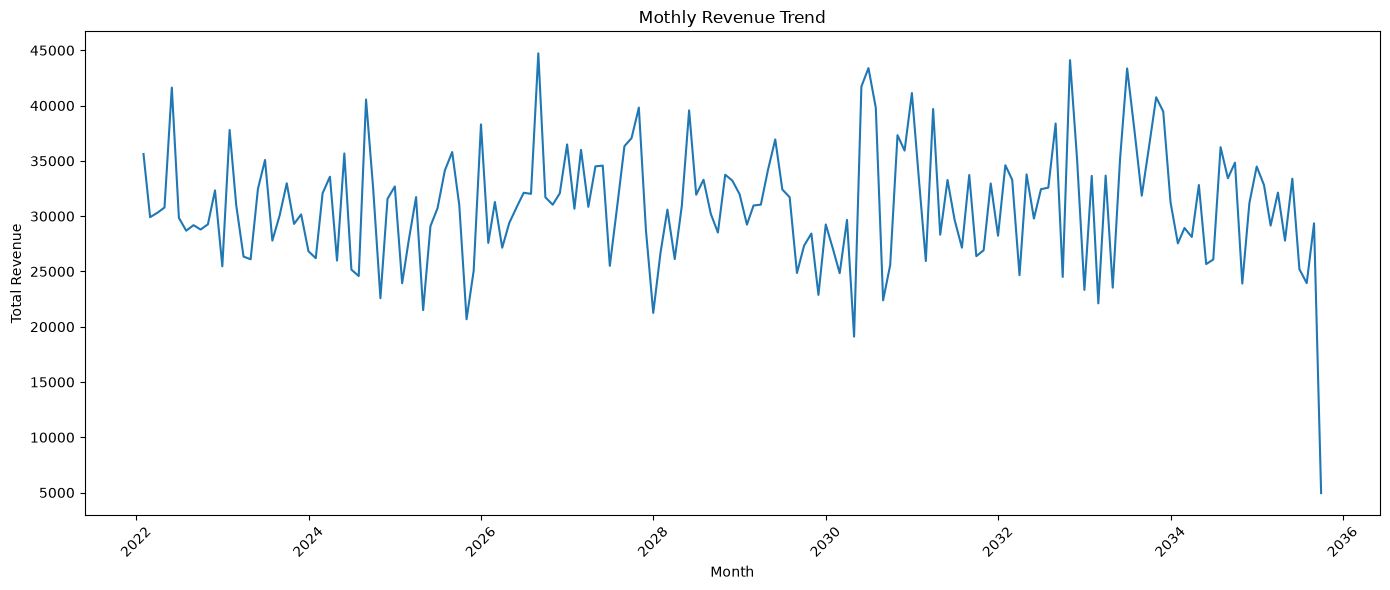

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(monthly_sales.index,monthly_sales.values)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
highest_month = monthly_sales.idxmax()
highest_month_revenue = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_month_revenue = monthly_sales.min()

print("Highest Revenue Month:", highest_month)
print("Highest Monthly Revenue:", highest_month_revenue)

print("Lowest Revenue Month:", lowest_month)
print("Lowest Monthly Revenue:", lowest_month_revenue)

Highest Revenue Month: 2026-08-31 00:00:00
Highest Monthly Revenue: 44728.82
Lowest Revenue Month: 2035-09-30 00:00:00
Lowest Monthly Revenue: 4952.2300000000005


In [ ]:
monthly_sales.mean()

np.float64(30968.33781818182)

In [ ]:
monthly_sales.std()

np.float64(5461.237812350013)

### Monthly Transaction Volume and Average Order Value

Revenue alone does not explain why a month performed differently. Comparing **transaction count** with **Average Order Value (AOV)** helps separate changes in customer volume from changes in spending per transaction.

In [ ]:
monthly_summary = df.set_index("order_date").resample("ME").agg({
    "order_id": "count",
    "revenue": "sum"
})

monthly_summary["AOV"] = (
    monthly_summary["revenue"] / monthly_summary["order_id"]
)

monthly_summary.head(10)

In [ ]:
highest_aov_month = monthly_summary["AOV"].idxmax()
highest_aov = monthly_summary["AOV"].max()

print("Highest AOV Month:", highest_aov_month)
print("Highest AOV:", round(highest_aov, 2))

**Business use:** In a real retail setting, a month with high revenue could be driven by more orders, higher-value orders, or both. AOV helps identify which explanation is more likely and provides a useful KPI for sales and marketing analysis.

### Monthly Revenue Interpretation

The monthly revenue trend shows fluctuations across the synthetic time period, with several higher and lower revenue months. This type of view can help an analyst monitor changes in sales performance and identify periods that may require further investigation.

The highest and lowest months in this dataset should **not** be interpreted as real-world seasonal events because the underlying dates are synthetic.

For a real business dataset, the next step would be to investigate whether changes are related to transaction volume, average order value, promotions, holidays, or product mix.

*Quarterly Revenue Analysis*

In [ ]:
quarterly_sales=(
    df.set_index("order_date")
    .resample("QE")["revenue"]
    .sum()
)
quarterly_sales.head()

order_date
2022-03-31     95843.06
2022-06-30    102258.53
2022-09-30     86663.76
2022-12-31     87058.95
2023-03-31     95118.92
Freq: QE-DEC, Name: revenue, dtype: float64

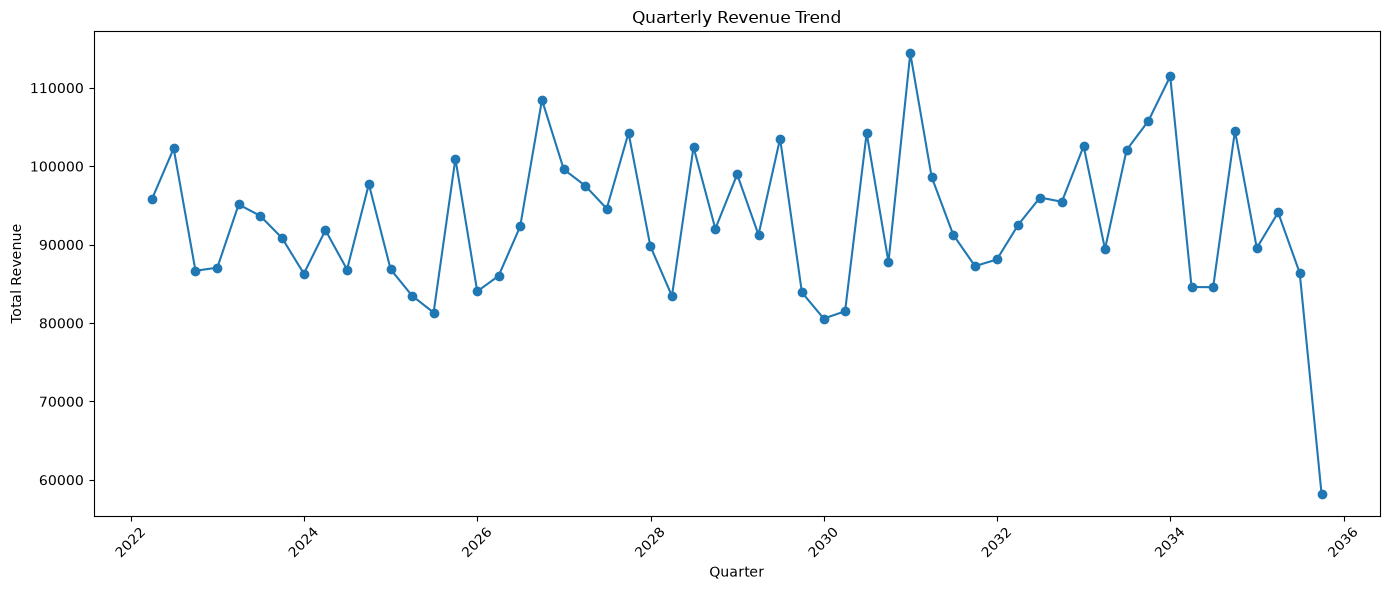

In [ ]:
plt.figure(figsize=(14, 6))

plt.plot(quarterly_sales.index, quarterly_sales.values, marker="o")

plt.title("Quarterly Revenue Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [ ]:
highest_quarter = quarterly_sales.idxmax()
highest_quarter_revenue = quarterly_sales.max()

lowest_quarter = quarterly_sales.idxmin()
lowest_quarter_revenue = quarterly_sales.min()

print("Highest Revenue Quarter:", highest_quarter)
print("Highest Quarterly Revenue:", highest_quarter_revenue)

print("Lowest Revenue Quarter:", lowest_quarter)
print("Lowest Quarterly Revenue:", lowest_quarter_revenue)

Highest Revenue Quarter: 2030-12-31 00:00:00
Highest Quarterly Revenue: 114391.98
Lowest Revenue Quarter: 2035-09-30 00:00:00
Lowest Quarterly Revenue: 58251.45


The quarterly revenue chart provides a broader view of sales performance compared with the monthly analysis.

Quarterly revenue also shows variation, with some quarters generating substantially higher revenue than others. The broader view helps reduce some of the short-term fluctuations visible in the monthly trend.

The highest and lowest performing quarters generated total revenue of **₹114391.98** and **₹58251.45** respectively.

**Customer demographics analysis**

Understanding customer demographics can help identify which customer groups generate more transaction activity and revenue. The analysis below first looks at transaction volume and then compares revenue by age group.

In [ ]:
#Checking the customers age range in the data
df["age"].min(), df["age"].max()       

(np.int64(18), np.int64(70))

In [ ]:
#Creating the age groups
age_bins = [17, 25, 35, 45, 55, 65, 100]   

age_labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "66+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=age_bins,
    labels=age_labels
)



In [ ]:
#Checking the number of transactions made by certain age groups.
age_group_counts = df["age_group"].value_counts().sort_index()

age_group_counts        

age_group
18-25     968
26-35    1247
36-45     864
46-55     972
56-65     821
66+       128
Name: count, dtype: int64

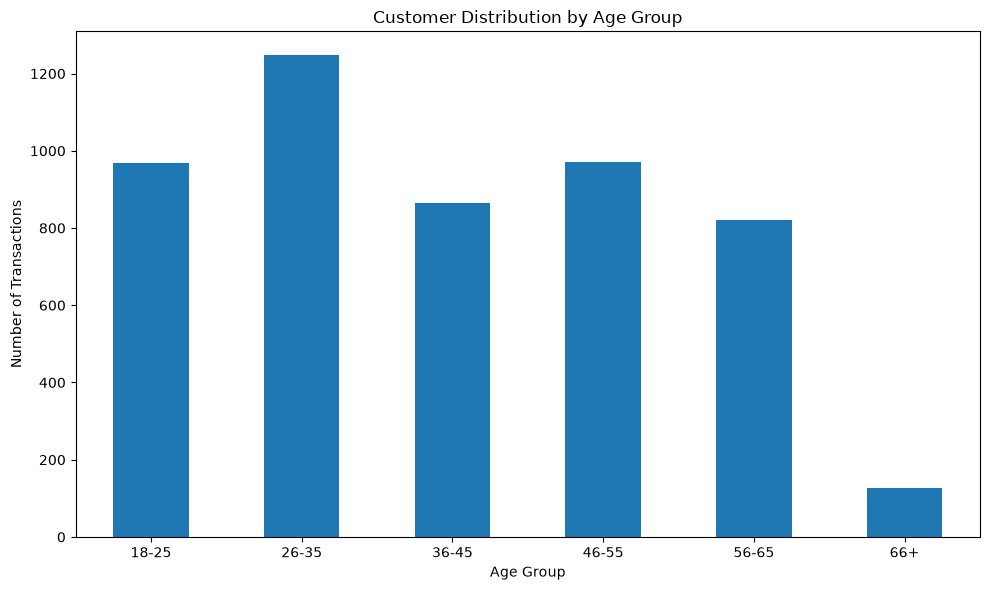

In [ ]:
plt.figure(figsize=(10, 6))

age_group_counts.plot(kind="bar")

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
most_common_age_group = age_group_counts.idxmax()
most_common_age_group_count = age_group_counts.max()

print("Most common age group:", most_common_age_group)
print("Number of transactions:", most_common_age_group_count)

Most common age group: 26-35
Number of transactions: 1247




The age-group analysis shows that customers aged **26–35** account for the highest number of transactions, making them the most active customers.

Customers aged **18–25** and **46–55** also contribute substantial transaction activity, while the **66+** age group has considerably fewer transactions.

The Customer Distribution by Age Group graph indicates that the business has stronger transaction activity among younger and middle-aged customers. However,Further analysis of revenue by age group would help determine whether the most frequent customer is also the most valuable in terms of spending.

In [ ]:
df["gender"].value_counts()

gender
Female    2607
Male      2393
Name: count, dtype: int64

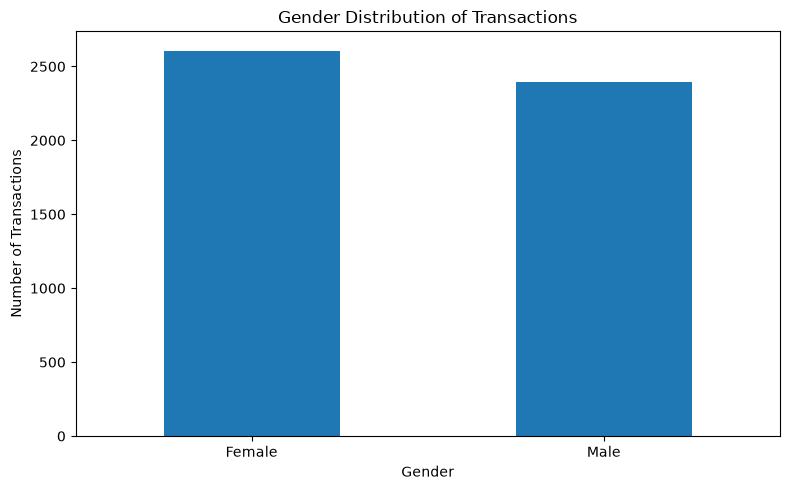

In [ ]:
gender_counts = df["gender"].value_counts()

plt.figure(figsize=(8, 5))

gender_counts.plot(kind="bar")

plt.title("Gender Distribution of Transactions")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
#Calulate the percentage of both the gender who make purchases
gender_percentage = df["gender"].value_counts(normalize=True) * 100

gender_percentage

gender
Female    52.14
Male      47.86
Name: proportion, dtype: float64

### Gender: Transactions vs Revenue

Transaction share alone does not show which group contributes more revenue, so I compared transaction count, total revenue, and average order value.

In [ ]:
gender_analysis = df.groupby("gender").agg(
    Transactions=("order_id", "count"),
    Revenue=("revenue", "sum")
)

gender_analysis["AOV"] = gender_analysis["Revenue"] / gender_analysis["Transactions"]
gender_analysis

This comparison gives a more complete view than transaction count alone. In a real business analysis, these results could be combined with product preferences, repeat purchases, and profit margin before making customer-targeting decisions.


The gender distribution is relatively balanced, although female customers account for a slightly higher number of transactions than male customers.

The difference between the two groups is not extremely large, suggesting that transaction activity is not heavily concentrated in one gender.

However, transaction count alone does not indicate which gender generates more revenue. 

**Product Analysis**

In [ ]:
df.columns.tolist()

['order_id',
 'order_date',
 'customer_id',
 'product_category',
 'region',
 'quantity',
 'unit_price',
 'discount',
 'payment_method',
 'delivery_days',
 'customer_rating',
 'revenue',
 'age',
 'gender',
 'age_group']

In [ ]:
df["product_category"].nunique()

4

In [ ]:
df["product_category"].value_counts()

product_category
Electronics    1777
Clothing       1531
Home            969
Beauty          723
Name: count, dtype: int64

In [ ]:
#Counting the number of items sold by each product category
category_quantity = (
    df.groupby("product_category")["quantity"]
      .sum()
      .sort_values(ascending=False)
)

category_quantity

product_category
Electronics    7109
Clothing       6171
Home           3949
Beauty         2995
Name: quantity, dtype: int64

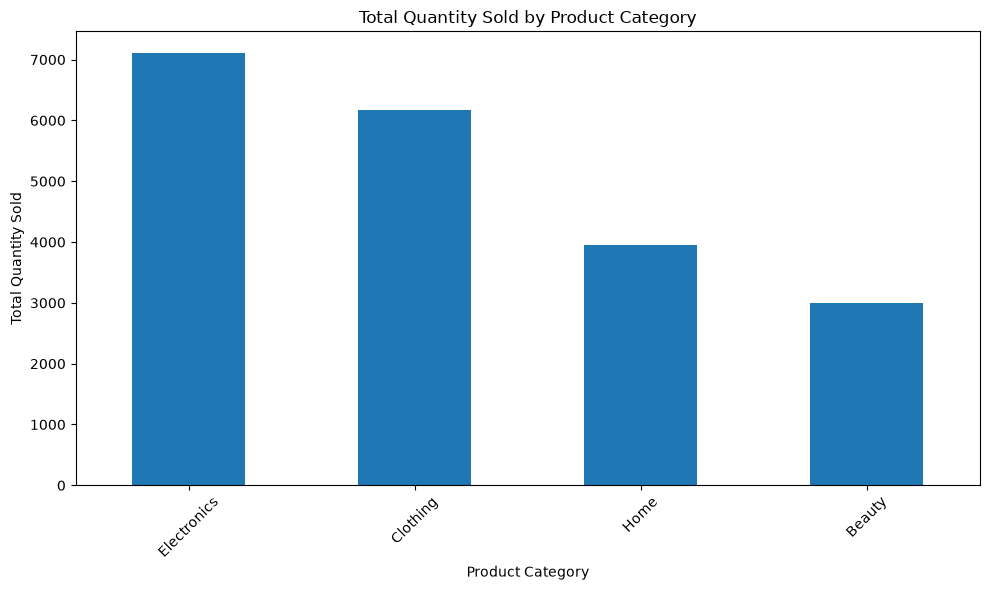

In [ ]:
plt.figure(figsize=(10, 6))

category_quantity.plot(kind="bar")

plt.title("Total Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Quantity Sold")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
best_category = category_quantity.idxmax()
best_category_quantity = category_quantity.max()

worst_category = category_quantity.idxmin()
worst_category_quantity = category_quantity.min()

print("Highest-selling category:", best_category)
print("Quantity sold:", best_category_quantity)

print("Lowest-selling category:", worst_category)
print("Quantity sold:", worst_category_quantity)

Highest-selling category: Electronics
Quantity sold: 7109
Lowest-selling category: Beauty
Quantity sold: 2995


In [ ]:
category_revenue = (
    df.groupby("product_category")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

category_revenue

product_category
Electronics    1829899.22
Clothing       1531931.72
Home            982083.92
Beauty          765860.88
Name: revenue, dtype: float64

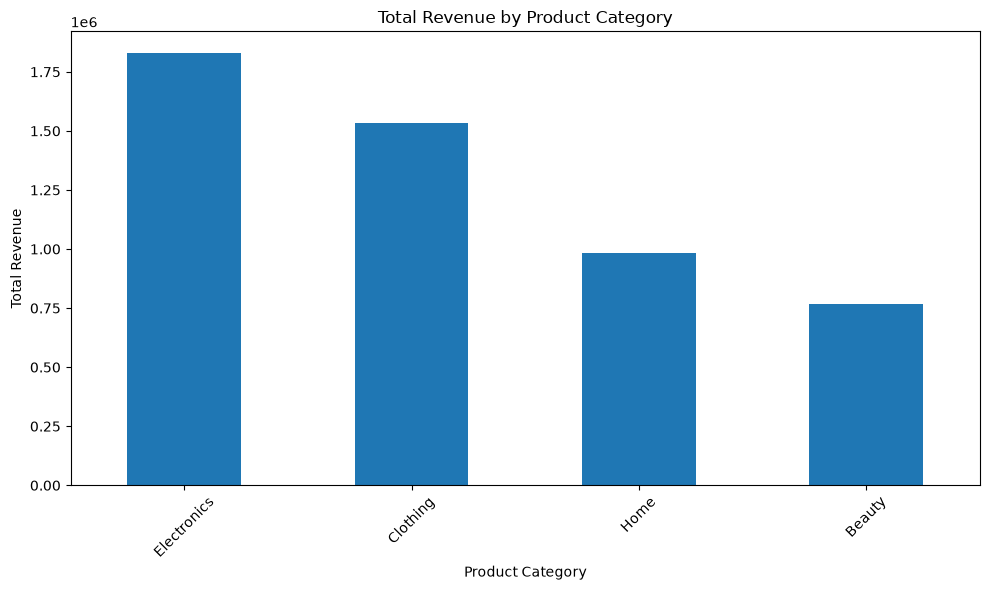

In [ ]:
plt.figure(figsize=(10, 6))

category_revenue.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [ ]:
highest_revenue_category = category_revenue.idxmax()
highest_category_revenue = category_revenue.max()

lowest_revenue_category = category_revenue.idxmin()
lowest_category_revenue = category_revenue.min()

print("Highest revenue category:", highest_revenue_category)
print("Revenue:", highest_category_revenue)

print("Lowest revenue category:", lowest_revenue_category)
print("Revenue:", lowest_category_revenue)

Highest revenue category: Electronics
Revenue: 1829899.22
Lowest revenue category: Beauty
Revenue: 765860.88


In [ ]:
category_analysis = pd.DataFrame({
    "Transactions": df.groupby("product_category")["order_id"].count(),
    "Total Quantity": category_quantity,
    "Total Revenue": category_revenue
})

category_analysis["AOV"] = (
    category_analysis["Total Revenue"] /
    category_analysis["Transactions"]
)

category_analysis

,Total Quantity,Total Revenue
product_category,,
Electronics,7109,1829899.22
Clothing,6171,1531931.72
Home,3949,982083.92
Beauty,2995,765860.88


In [ ]:
category_analysis["Revenue per Unit"] = (
    category_analysis["Total Revenue"] /
    category_analysis["Total Quantity"]
)

category_analysis

,Total Quantity,Total Revenue,Revenue per Unit
product_category,,,
Electronics,7109,1829899.22,257.405995
Clothing,6171,1531931.72,248.246916
Home,3949,982083.92,248.691800
Beauty,2995,765860.88,255.713149


### Product Performance Interpretation

**Electronics** is the strongest-performing category in this dataset, recording **7,109 units sold** and approximately **₹1.83 million in revenue**. **Clothing** follows with **6,171 units** and approximately **₹1.53 million in revenue**.

Home generated approximately **₹982,084** from **3,949 units**, while Beauty recorded the lowest sales volume and revenue among the four categories.

The comparison of quantity, revenue, and revenue per unit helps distinguish whether a category performs strongly because of sales volume, transaction value, or a combination of both.

**Business use:** In a real retail environment, these results could be used as a starting point for reviewing inventory levels, product availability, pricing, promotions, and category-level demand. The dataset alone does not establish that a category needs more inventory or promotion, so those decisions would require additional operational data.

**Heatmap - correlation matrix**

In [ ]:
df.corr(numeric_only=True)

,order_id,customer_id,quantity,unit_price,discount,delivery_days,customer_rating,revenue,age
order_id,1.000000,0.017504,-0.003368,0.017876,0.011110,0.006196,0.004984,0.009681,0.010482
customer_id,0.017504,1.000000,0.023097,0.009748,-0.012617,-0.017440,0.020302,0.025499,-0.007262
quantity,-0.003368,0.023097,1.000000,0.001498,-0.004302,-0.008748,0.019168,0.623564,-0.007457
unit_price,0.017876,0.009748,0.001498,1.000000,0.013215,0.015623,0.005025,0.678032,0.005154
discount,0.011110,-0.012617,-0.004302,0.013215,1.000000,-0.000382,0.012776,-0.139296,-0.010709
delivery_days,0.006196,-0.017440,-0.008748,0.015623,-0.000382,1.000000,-0.017625,0.005444,-0.013299
customer_rating,0.004984,0.020302,0.019168,0.005025,0.012776,-0.017625,1.000000,0.012446,0.005166
revenue,0.009681,0.025499,0.623564,0.678032,-0.139296,0.005444,0.012446,1.000000,0.002007
age,0.010482,-0.007262,-0.007457,0.005154,-0.010709,-0.013299,0.005166,0.002007,1.000000


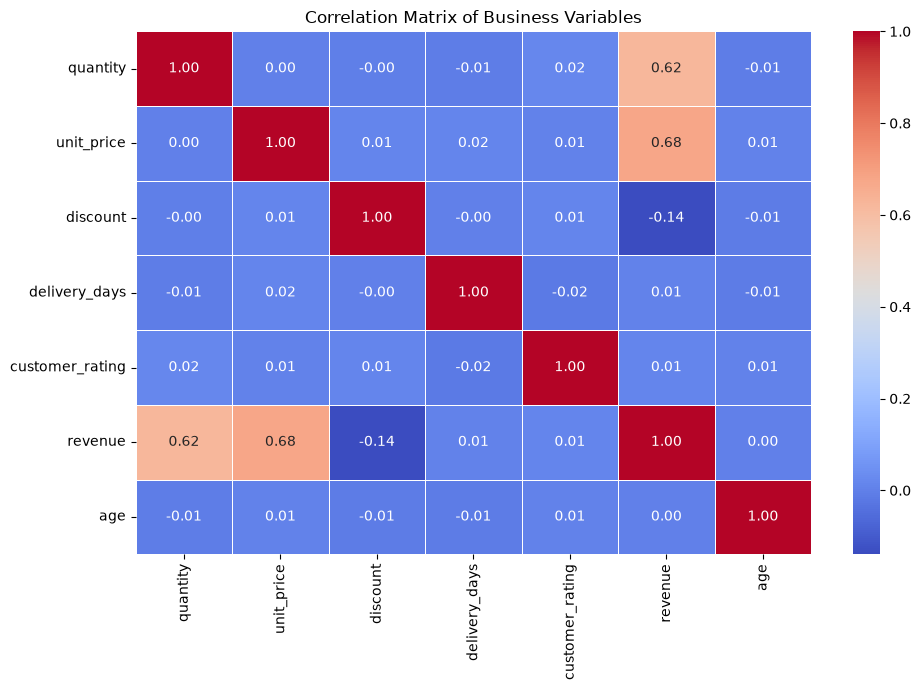

In [ ]:
numeric_columns = [
    "quantity",
    "unit_price",
    "discount",
    "delivery_days",
    "customer_rating",
    "revenue",
    "age"
]

correlation_matrix = df[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Matrix of Business Variables")

plt.tight_layout()
plt.show()

### Correlation Interpretation

- **Unit price (0.68)** and **quantity (0.62)** show the strongest positive relationships with revenue in this dataset.
- **Discount (-0.14)** shows a weak negative relationship with revenue.
- **Age, delivery days, and customer rating** have very weak relationships with revenue.

These values describe relationships, **not cause and effect**.

There is also an important limitation: revenue is calculated from transaction-level variables including **quantity, unit price, and discount**. Therefore, the relatively strong correlations between these variables and revenue are partly expected from the way revenue is constructed. They should not be presented as proof that changing one variable will automatically increase revenue.

For deeper business analysis, profit margin, customer history, marketing spend, and product-level information would be useful additional variables.

**Additional Visualizations**

Revenue by Age Group

In [ ]:
age_group_revenue = (
    df.groupby("age_group", observed=True)["revenue"]
      .sum()
      .sort_values(ascending=False)
)

age_group_revenue

age_group
26-35    1318515.35
46-55     993700.40
18-25     977784.35
56-65     842093.56
36-45     841850.20
66+       135831.88
Name: revenue, dtype: float64

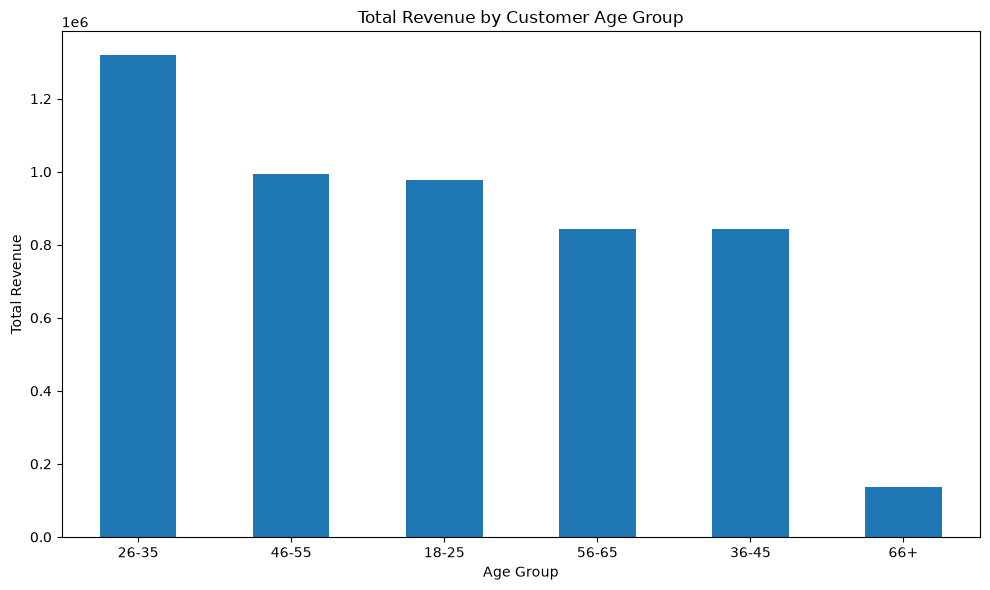

In [ ]:
plt.figure(figsize=(10, 6))

age_group_revenue.plot(kind="bar")

plt.title("Total Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
highest_revenue_age_group = age_group_revenue.idxmax()
highest_age_group_revenue = age_group_revenue.max()

lowest_revenue_age_group = age_group_revenue.idxmin()
lowest_age_group_revenue = age_group_revenue.min()

print("Highest revenue age group:", highest_revenue_age_group)
print("Revenue:", highest_age_group_revenue)

print("Lowest revenue age group:", lowest_revenue_age_group)
print("Revenue:", lowest_age_group_revenue)

Highest revenue age group: 26-35
Revenue: 1318515.35
Lowest revenue age group: 66+
Revenue: 135831.88


### Age Group Revenue Interpretation

Customers aged **26–35** generate the highest total revenue at approximately **₹1.32 million**, consistent with their position as the highest-transaction age group.

Customers aged **46–55** and **18–25** are the next largest contributors, while the **66+** group contributes the lowest revenue in the dataset.

The 26–35 segment is therefore the largest segment by both transaction count and total revenue in this synthetic dataset. This makes it a useful segment for further analysis of product preferences, repeat purchases, and customer retention.

**Business use:** A real retailer could use this analysis to identify segments for deeper customer profiling. However, total revenue alone does not establish that one age group is more profitable than another; margin and customer lifetime value would be needed for that conclusion.

**Customer payment method**

In [189]:
df["payment_method"].value_counts()

payment_method
Card      2270
COD       1774
Wallet     956
Name: count, dtype: int64

In [190]:
payment_revenue = (
    df.groupby("payment_method")["revenue"]
      .sum()
      .sort_values(ascending=False)
)

payment_revenue

payment_method
Card      2366248.20
COD       1788408.44
Wallet     955119.10
Name: revenue, dtype: float64

### Payment Method: Transactions, Revenue and AOV

Payment preference is more useful when transaction volume is considered alongside revenue and Average Order Value.

In [ ]:
payment_analysis = df.groupby("payment_method").agg(
    Transactions=("order_id", "count"),
    Revenue=("revenue", "sum")
)

payment_analysis["AOV"] = payment_analysis["Revenue"] / payment_analysis["Transactions"]
payment_analysis["Revenue Share (%)"] = (
    payment_analysis["Revenue"] / payment_analysis["Revenue"].sum() * 100
)

payment_analysis.sort_values("Revenue", ascending=False)

**Business use:** This comparison can help a retailer monitor checkout preferences and transaction value by payment method. A real business could use it when reviewing payment availability, checkout reliability, and customer experience.

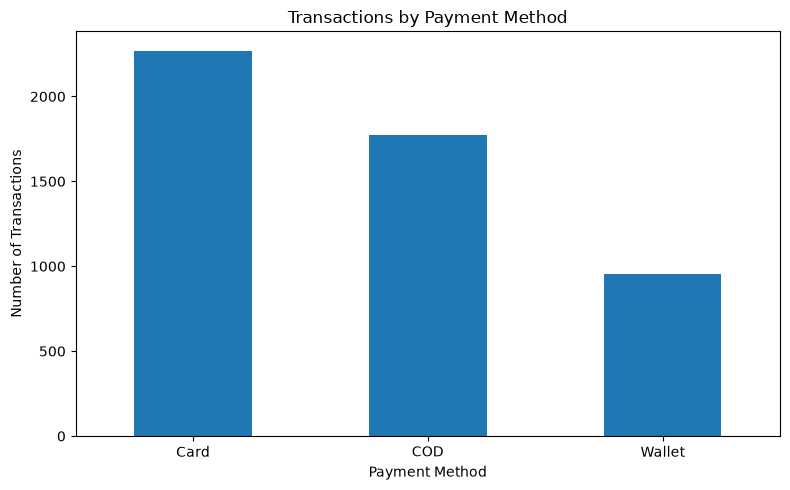

In [191]:
plt.figure(figsize=(8, 5))

df["payment_method"].value_counts().plot(kind="bar")

plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Payment Method Interpretation

**Card** is the most frequently used payment method, with **2,270 transactions**, and it also contributes the highest total revenue at approximately **₹2.37 million**.

Comparing transaction count, revenue, and AOV provides a better view of payment behavior than transaction count alone. In a real business, these metrics could be monitored to understand checkout preferences and whether certain payment methods are associated with different order values.

## Conclusion

This project used exploratory data analysis to examine **5,000 synthetic retail transactions** across sales trends, customer segments, product categories, payment methods, and numerical relationships.

### Main findings

1. **Electronics** is the strongest product category, with **7,109 units sold** and approximately **₹1.83 million in revenue**.
2. Customers aged **26–35** have the highest transaction activity and generate approximately **₹1.32 million in revenue**.
3. **Card** is the most-used payment method, with **2,270 transactions** and approximately **₹2.37 million in revenue**.
4. **Unit price (0.68)** and **quantity (0.62)** have the strongest positive correlations with revenue, while discount shows a weak negative correlation (**-0.14**).
5. **Average Order Value (AOV)** was added to distinguish transaction volume from transaction value and provide a more useful business KPI.

### Business interpretation

These findings can be used as starting points for:
- reviewing category-level inventory and sales performance,
- understanding customer segments for further marketing analysis,
- monitoring payment preferences and checkout behavior,
- evaluating pricing, quantity, and discount patterns,
- identifying areas that need deeper investigation.

The recommendations should be treated as **areas for further investigation rather than direct causal conclusions**. For example, high Electronics revenue does not by itself prove that inventory should be increased, and the correlation results do not prove that changing price or quantity will increase revenue.

### Limitations and next steps

This dataset is **synthetic and created for analytical practice**, so the date range does not represent real historical retail activity. Time-based findings should therefore be viewed as examples of how an analyst would perform trend analysis rather than real market trends.

For a more complete retail analysis, useful additional data would include:
- profit margin and cost data,
- customer purchase history and repeat orders,
- marketing campaign spend and conversions,
- inventory levels and stock-outs,
- product-level information,
- returns and cancellations.

These additional variables would allow the analysis to move beyond sales description toward profitability, customer value, inventory planning, and marketing performance.